### Step 4 - ML Model Training for MDR-TB Prediction
### Objective 2: Explainable Machine Learning for Genomic Feature Prioritisation

**Dataset:** 1,857 samples × 94,583 variant features | MDR: 871 (46.9%) | non-MDR: 986

---

In [1]:
import os, time, pickle, json, warnings, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13})
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (roc_auc_score, f1_score, precision_score, recall_score, accuracy_score, confusion_matrix)
from sklearn.base import BaseEstimator, TransformerMixin

import xgboost as xgb
from interpret.glassbox import ExplainableBoostingClassifier

In [2]:
from pathlib import Path
HOME  = Path.cwd().parent.parent
print(HOME)

n:\3_BIOINFO\AMR_Mtb_intern


In [3]:

BASE  = os.path.join(HOME, "art_model")
STEP1 = os.path.join(BASE, "ml_outputs", "step1_dataset")
STEP4 = os.path.join(BASE, "ml_outputs", "step4_models")

os.makedirs(STEP4, exist_ok=True)
os.makedirs(os.path.join(STEP4, "trained_models"), exist_ok=True)

print(f"Inputs : {STEP1}")
print(f"Outputs: {STEP4}")

Inputs : n:\3_BIOINFO\AMR_Mtb_intern\art_model\ml_outputs\step1_dataset
Outputs: n:\3_BIOINFO\AMR_Mtb_intern\art_model\ml_outputs\step4_models


In [4]:
import psutil
t0 = time.time()

x      = np.load(os.path.join(STEP1, "X_array.npy"))
y      = np.load(os.path.join(STEP1, "y_mdr_array.npy"))
y_pre  = np.load(os.path.join(STEP1, "y_pre_xdr_array.npy"))
y_xdr  = np.load(os.path.join(STEP1, "y_xdr_array.npy"))
labels = pd.read_csv(os.path.join(STEP1, "y_labels.csv"))

with open(os.path.join(STEP1, "feature_names_clean.txt")) as f:
    feature_names = [l.strip() for l in f if l.strip()]

print(f"Loaded in {time.time()-t0:.1f}s")
print(f"X shape: {x.shape}  (samples x variants)")
print(f"X dtype: {x.dtype}  (uint8 = 1 byte per cell)")
print(f"X RAM: {x.nbytes/1e6:.0f} MB")
print(f"MDR: {y.sum()} ({y.mean()*100:.1f}%)")
print(f"non-MDR: {(y==0).sum()} ({(y==0).mean()*100:.1f}%)")
print(f"Sparsity: {(x==0).mean()*100:.1f}% zeros")
print()
ram = psutil.virtual_memory()
print(f"System RAM   : {ram.total/1e9:.1f} GB total | {ram.available/1e9:.1f} GB available")

Loaded in 0.2s
X shape: (1857, 94583)  (samples x variants)
X dtype: uint8  (uint8 = 1 byte per cell)
X RAM: 176 MB
MDR: 871 (46.9%)
non-MDR: 986 (53.1%)
Sparsity: 97.4% zeros

System RAM   : 16.8 GB total | 6.2 GB available


In [5]:
# Sanity
assert x.shape[0] == len(y)
assert x.shape[1] == len(feature_names)

In [6]:
N_FOLDS    = 5
K_FEATURES = 5000
SCALE_POS  = float((y == 0).sum()) / float((y == 1).sum())  # ~1.13

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

SCORING = {
    'roc_auc'  : 'roc_auc',
    'f1'       : 'f1',
    'precision': 'precision',
    'recall'   : 'recall',
    'accuracy' : 'accuracy',
}
METRICS = ['roc_auc', 'f1', 'precision', 'recall', 'accuracy']

def print_cv(cv_res, name):
    print(f"  {name}")
    for m in METRICS:
        v = cv_res[f'test_{m}']
        print(f"  {m.upper():<12}: {v.mean():.4f} ± {v.std():.4f}  "
              f"[{v.min():.4f} – {v.max():.4f}]")

def save_model(obj, fname):
    path = os.path.join(STEP4, "trained_models", fname)
    pickle.dump(obj, open(path, 'wb'))
    size = os.path.getsize(path)
    print(f"  Saved: {fname}  ({size/1024:.0f} KB)")

def ram_check(label=""):
    ram = psutil.virtual_memory()
    print(f"  RAM [{label}]: {ram.used/1e9:.1f} GB used | {ram.available/1e9:.1f} GB free")

print(f"CV           : {N_FOLDS}-fold stratified")
print(f"K_FEATURES   : {K_FEATURES:,}  (for LR + EBM pipelines)")
print(f"scale_pos_w  : {SCALE_POS:.3f}  (for XGBoost)")

CV           : 5-fold stratified
K_FEATURES   : 5,000  (for LR + EBM pipelines)
scale_pos_w  : 1.132  (for XGBoost)


---
#### Float32 Transformer (RAM Fix)

`SelectKBest` outputs `float64` by default - doubling memory unnecessarily.  
This custom transformer casts to `float32` after chi2 selection, halving the RAM  
cost of the selected feature matrix inside the pipeline.


In [7]:
class ToFloat32(BaseEstimator, TransformerMixin):
    def fit(self, x, y=None):
        return self
    def transform(self, x, y=None):
        return x.astype(np.float32)

def make_lor_pipeline(C=0.1, k=K_FEATURES):
    return Pipeline([
        ('chi2',    SelectKBest(chi2, k=k)),
        ('f32',     ToFloat32()),
        ('model',   LogisticRegression(
            C=C, penalty='l2', solver='saga',
            max_iter=1000, class_weight='balanced',
            random_state=42, n_jobs=2))
    ])

def make_rf_pipeline(n_estimators=300, max_features='sqrt', min_samples_leaf=5, min_samples_split=10):
    return Pipeline([
        ('model', RandomForestClassifier(
            n_estimators=n_estimators,
            max_features=max_features,
            min_samples_leaf=min_samples_leaf,
            min_samples_split=min_samples_split,
            max_depth=20,         
            class_weight='balanced',
            oob_score=True,
            random_state=42,
            n_jobs=2))           
    ])

def make_xgb_pipeline(n_estimators=500, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.3, min_child_weight=5, reg_alpha=0.1, reg_lambda=1.0):
    return Pipeline([
        ('model', xgb.XGBClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            min_child_weight=min_child_weight,
            reg_alpha=reg_alpha,
            reg_lambda=reg_lambda,
            scale_pos_weight=SCALE_POS,
            tree_method='hist',
            device='cpu',
            eval_metric='auc',
            random_state=42,
            n_jobs=2))           
    ])

def make_ebm_pipeline(k=K_FEATURES, outer_bags=4, interactions=5):
    return Pipeline([
        ('chi2',  SelectKBest(chi2, k=k)),
        ('f32',   ToFloat32()),
        ('model', ExplainableBoostingClassifier(
            max_bins=64,
            max_interaction_bins=16,  
            interactions=interactions,
            outer_bags=outer_bags,  
            inner_bags=0,
            learning_rate=0.01,
            validation_size=0.15,
            min_samples_leaf=2,
            max_leaves=3,
            random_state=42,
            n_jobs=1))
    ])


### Model 1 - LOR as baseline model

**Pipeline:** `chi2(top 5,000)` → `float32` → `LogisticRegression(C=0.1, L2)`  
**Why C=0.1:** With 5,000 features, moderate regularisation shrinks noisy coefficients.  
**Why L2:** Ridge handles correlated SNPs - many linked variants carry similar signal.


In [8]:
t0 = time.time()

lor_pipe = make_lor_pipeline(C=0.1, k=K_FEATURES)

lor_cv = cross_validate(
    lor_pipe, x, y,
    cv=skf, scoring=SCORING,
    return_train_score=True,
)
lor_cv

{'fit_time': array([46.62790918, 15.13985109, 15.69325876, 16.84531474, 11.07521725]),
 'score_time': array([0.03603077, 0.03155327, 0.03555846, 0.03389239, 0.02847195]),
 'test_roc_auc': array([0.89209625, 0.88306019, 0.90100064, 0.89555983, 0.89582239]),
 'train_roc_auc': array([0.96883489, 0.96719895, 0.96229995, 0.96304732, 0.96176171]),
 'test_f1': array([0.84097035, 0.83060109, 0.85479452, 0.82681564, 0.83380282]),
 'train_f1': array([0.90358127, 0.90446735, 0.89224434, 0.90048044, 0.89437586]),
 'test_precision': array([0.79187817, 0.79581152, 0.81675393, 0.80434783, 0.81767956]),
 'train_precision': array([0.86887417, 0.86693017, 0.85526316, 0.86315789, 0.85676741]),
 'test_recall': array([0.89655172, 0.86857143, 0.89655172, 0.85057471, 0.85057471]),
 'train_recall': array([0.94117647, 0.9454023 , 0.93256815, 0.94117647, 0.93543759]),
 'test_accuracy': array([0.84139785, 0.83333333, 0.85714286, 0.8328841 , 0.84097035]),
 'train_accuracy': array([0.90572391, 0.90639731, 0.894347

In [9]:
print(f"model training done in {time.time()-t0:.1f}s")
print_cv(lor_cv, "logistic regression")

lor_pipe.fit(x, y)
# save_model(lor_pipe, "lor_pipeline.pkl")

gc.collect()

model training done in 106.0s
  logistic regression
  ROC_AUC     : 0.8935 ± 0.0059  [0.8831 – 0.9010]
  F1          : 0.8374 ± 0.0099  [0.8268 – 0.8548]
  PRECISION   : 0.8053 ± 0.0105  [0.7919 – 0.8177]
  RECALL      : 0.8726 ± 0.0207  [0.8506 – 0.8966]
  ACCURACY    : 0.8411 ± 0.0088  [0.8329 – 0.8571]


315

### Model 2 - Random Forest

**Pipeline:** `RandomForestClassifier(300 trees, max_depth=20, n_jobs=2)`   
**Why 300 trees instead of 500:** 300 is enough for stable feature importance; saves RAM and time.  
**Why max_depth=20:** Limits tree size - prevents the exponential node growth that kills RAM.


In [14]:
t0 = time.time()

rf_pipe = make_rf_pipeline(
    n_estimators=300,
    max_features='sqrt',
    min_samples_leaf=5,
    min_samples_split=10
)

rf_cv = cross_validate(
    rf_pipe, x, y,
    cv=skf, scoring=SCORING,
    return_train_score=True,
    n_jobs=1 
)
rf_cv

{'fit_time': array([28.92238212, 51.51359248, 49.49764562, 52.97583532, 40.45392084]),
 'score_time': array([0.3751533 , 0.32257509, 0.33648658, 0.43872452, 0.422436  ]),
 'test_roc_auc': array([0.90514339, 0.85534445, 0.90679153, 0.89372192, 0.88835405]),
 'train_roc_auc': array([0.93133007, 0.93411382, 0.93032424, 0.93033697, 0.93099341]),
 'test_f1': array([0.84065934, 0.79452055, 0.8255814 , 0.81142857, 0.81690141]),
 'train_f1': array([0.85852312, 0.86347886, 0.85357391, 0.85989011, 0.8511822 ]),
 'test_precision': array([0.80526316, 0.76315789, 0.83529412, 0.80681818, 0.80110497]),
 'train_precision': array([0.82712766, 0.83400268, 0.8266129 , 0.82476943, 0.82591093]),
 'test_recall': array([0.87931034, 0.82857143, 0.81609195, 0.81609195, 0.83333333]),
 'train_recall': array([0.89239598, 0.89511494, 0.88235294, 0.89813486, 0.87804878]),
 'test_accuracy': array([0.84408602, 0.7983871 , 0.83827493, 0.82210243, 0.82479784]),
 'train_accuracy': array([0.86195286, 0.86734007, 0.858008

In [15]:
print(f"model training done in {time.time()-t0:.1f}s")
print_cv(rf_cv, "random forest")

rf_pipe.fit(x, y)
print(f"OOB score: {rf_pipe['model'].oob_score_:.4f}")
# save_model(rf_pipe, "rf_pipeline.pkl")

gc.collect()

model training done in 231.6s
  random forest
  ROC_AUC     : 0.8899 ± 0.0186  [0.8553 – 0.9068]
  F1          : 0.8178 ± 0.0153  [0.7945 – 0.8407]
  PRECISION   : 0.8023 ± 0.0230  [0.7632 – 0.8353]
  RECALL      : 0.8347 ± 0.0233  [0.8161 – 0.8793]
  ACCURACY    : 0.8255 ± 0.0158  [0.7984 – 0.8441]
OOB score: 0.8331


412

### Model 3 - XGBoost

**Pipeline:** `XGBClassifier(hist, 500 rounds, depth=6, colsample=0.3, n_jobs=2)`  
**Why XGB is the most RAM-efficient tree model:**  
- `tree_method='hist'` builds histogram bins once then reuses them - very memory efficient  
- `colsample_bytree=0.3` uses only 30% of features per tree ≈ 28,000 features per round  
- Skips zero values natively - 97.4% sparsity means it processes very few actual values  
**Why XGB is the best model for this data:** Gradient boosting consistently outperforms RF  
on sparse binary genomic SNP matrices in published literature.


In [18]:
t0 = time.time()

xgb_pipe = make_xgb_pipeline(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.3,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0
)

xgb_cv = cross_validate(
    xgb_pipe, x, y,
    cv=skf, scoring=SCORING,
    return_train_score=True,
)

xgb_cv

{'fit_time': array([396.35293245, 284.86077118, 333.00674224, 329.15846372,
        330.30722117]),
 'score_time': array([0.69363236, 0.45497131, 0.4580369 , 0.45719266, 0.46131563]),
 'test_roc_auc': array([0.89559387, 0.89099347, 0.90318863, 0.91522259, 0.90935877]),
 'train_roc_auc': array([0.99636222, 0.99597282, 0.99647048, 0.99684234, 0.99639047]),
 'test_f1': array([0.85245902, 0.82833787, 0.83195592, 0.85082873, 0.83380282]),
 'train_f1': array([0.97546898, 0.9775525 , 0.97687861, 0.97771387, 0.97617329]),
 'test_precision': array([0.8125    , 0.79166667, 0.7989418 , 0.81914894, 0.81767956]),
 'train_precision': array([0.98113208, 0.98540146, 0.98398836, 0.97982709, 0.98255814]),
 'test_recall': array([0.89655172, 0.86857143, 0.86781609, 0.88505747, 0.85057471]),
 'train_recall': array([0.96987088, 0.96982759, 0.96987088, 0.97560976, 0.96987088]),
 'test_accuracy': array([0.85483871, 0.83064516, 0.83557951, 0.85444744, 0.84097035]),
 'train_accuracy': array([0.97710438, 0.97912

In [19]:
print(f"model training done in {time.time()-t0:.1f}s")
print_cv(xgb_cv, "XgBoost model")

xgb_pipe.fit(x, y)
save_model(xgb_pipe, "xgb_pipeline.pkl")
# Also save XGB model in native format for SHAP in Step 5
# xgb_pipe['model'].save_model(os.path.join(STEP4, "trained_models", "xgb_model.json"))

# gc.collect()

model training done in 1686.0s
  XgBoost model
  ROC_AUC     : 0.9029 ± 0.0088  [0.8910 – 0.9152]
  F1          : 0.8395 ± 0.0101  [0.8283 – 0.8525]
  PRECISION   : 0.8080 ± 0.0108  [0.7917 – 0.8191]
  RECALL      : 0.8737 ± 0.0158  [0.8506 – 0.8966]
  ACCURACY    : 0.8433 ± 0.0098  [0.8306 – 0.8548]
  Saved: xgb_pipeline.pkl  (763 KB)


### Model 4 - EBM GlassBox

**Pipeline:** `chi2(5,000)` → `float32` → `EBM(outer_bags=4, interactions=5, n_jobs=1)`

**Why EBM:**  
EBM is the **only natively interpretable model** in this comparison. It learns a  
shape function for each feature - you can directly plot how each variant contributes  
to MDR probability without any post-hoc SHAP calculation. For a publication claiming  
explainability, EBM's native interpretability is stronger evidence than SHAP on a black-box.

In [10]:
K_EBM = 5000 
t0 = time.time()

ebm_pipe = make_ebm_pipeline(
    k=K_EBM,
    outer_bags=5,   
    interactions=7,  
)

ebm_cv = cross_validate(
    ebm_pipe, x, y,
    cv=skf, scoring=SCORING,
    return_train_score=True,
    n_jobs=1
)

ebm_cv

{'fit_time': array([ 968.36131597, 1209.99558377, 1142.57516456, 1072.58949447,
        1010.40454817]),
 'score_time': array([0.2702949 , 0.38914132, 0.43283439, 0.52040124, 0.3817122 ]),
 'test_roc_auc': array([0.89868513, 0.87580856, 0.90741875, 0.8927592 , 0.90428263]),
 'train_roc_auc': array([0.92923443, 0.93417665, 0.92874859, 0.93206172, 0.92456627]),
 'test_f1': array([0.84615385, 0.81440443, 0.84916201, 0.81818182, 0.84269663]),
 'train_f1': array([0.85073581, 0.86433566, 0.85236769, 0.86565097, 0.85872576]),
 'test_precision': array([0.81052632, 0.79032258, 0.82608696, 0.80898876, 0.82417582]),
 'train_precision': array([0.83150685, 0.84196185, 0.82814614, 0.83668005, 0.82998661]),
 'test_recall': array([0.88505747, 0.84      , 0.87356322, 0.82758621, 0.86206897]),
 'train_recall': array([0.87087518, 0.88793103, 0.87804878, 0.89670014, 0.88952654]),
 'test_accuracy': array([0.84946237, 0.81989247, 0.85444744, 0.82749326, 0.8490566 ]),
 'train_accuracy': array([0.85656566, 0.

In [11]:
print(f"model training done in {time.time()-t0:.1f}s")
print_cv(ebm_cv, f"EBM GlassBox model")

ebm_pipe.fit(x, y)

# selected_mask     = ebm_pipe['chi2'].get_support()
# ebm_feature_names = [feature_names[i] for i, s in enumerate(selected_mask) if s]

# save_model(
#     {'pipeline': ebm_pipe, 'feature_names': ebm_feature_names, 'k': K_EBM}, "ebm_pipeline.pkl"
# )

# gc.collect()

model training done in 10579.7s
  EBM GlassBox model
  ROC_AUC     : 0.8958 ± 0.0112  [0.8758 – 0.9074]
  F1          : 0.8341 ± 0.0147  [0.8144 – 0.8492]
  PRECISION   : 0.8120 ± 0.0129  [0.7903 – 0.8261]
  RECALL      : 0.8577 ± 0.0212  [0.8276 – 0.8851]
  ACCURACY    : 0.8401 ± 0.0137  [0.8199 – 0.8544]


,steps,"[('chi2', ...), ('f32', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,score_func,<function chi...001DEA8EC60C0>
,k,5000
,feature_names,None
,feature_types,None
,max_bins,64
,max_interaction_bins,16
,interactions,7


In [12]:
# Fix EBM feature names — map feature_XXXX back to Chromosome_POS_REF_ALT
selected_mask     = ebm_pipe['chi2'].get_support()
ebm_feat_names    = [feature_names[i] for i, s in enumerate(selected_mask) if s]

# Rebuild EBM importance with real names
ebm_explanation   = ebm_pipe['model'].explain_global()
raw_names         = ebm_explanation.data()['names']
raw_scores        = ebm_explanation.data()['scores']

# Map feature_XXXX → real name
def resolve_name(name):
    # Handle interaction terms: "feature_0123 & feature_0456"
    if ' & ' in name:
        parts = name.split(' & ')
        resolved = []
        for p in parts:
            if p.startswith('feature_'):
                idx = int(p.replace('feature_', '').lstrip('0') or '0')
                resolved.append(ebm_feat_names[idx] if idx < len(ebm_feat_names) else p)
            else:
                resolved.append(p)
        return ' & '.join(resolved)
    elif name.startswith('feature_'):
        idx = int(name.replace('feature_', '').lstrip('0') or '0')
        return ebm_feat_names[idx] if idx < len(ebm_feat_names) else name
    return name

ebm_imp_df_fixed = pd.DataFrame({
    'feature'    : [resolve_name(n) for n in raw_names],
    'importance' : raw_scores,
}).sort_values('importance', ascending=False).reset_index(drop=True)
ebm_imp_df_fixed['rank'] = range(1, len(ebm_imp_df_fixed)+1)

# Save with real names
ebm_imp_df_fixed.to_csv(os.path.join(STEP4, 'obj2_ebm_feature_importance_named.csv'), index=False)
print("Saved: obj2_ebm_feature_importance_named.csv")
print()
print("Top 15 EBM features (with real names):")
print(ebm_imp_df_fixed[['rank','feature','importance']].head(15).to_string(index=False))

Saved: obj2_ebm_feature_importance_named.csv

Top 15 EBM features (with real names):
 rank                                                           feature  importance
    1                    Chromosome_761155_C_T & Chromosome_2866503_G_A    0.139908
    2                    Chromosome_338435_G_C & Chromosome_1313338_A_C    0.135862
    3                    Chromosome_663419_G_A & Chromosome_2155168_C_G    0.080990
    4                    Chromosome_663420_C_A & Chromosome_2155168_C_G    0.080788
    5                   Chromosome_2626244_G_C & Chromosome_4186898_G_C    0.078750
    6                   Chromosome_1313338_A_C & Chromosome_2155168_C_G    0.076406
    7                                            Chromosome_2155168_C_G    0.059217
    8                                            Chromosome_1313338_A_C    0.041459
    9                                             Chromosome_761155_C_T    0.031927
   10                                            Chromosome_3478719_G_A    

#### Full Model Comparison Table

In [20]:
all_cv = {
    'Logistic Regression': lor_cv,
    'Random Forest'      : rf_cv,
    'XGBoost'            : xgb_cv,
    'EBM GlassBox'       : ebm_cv,
}

rows = []
for name, cv in all_cv.items():
    row = {'Model': name}
    for m in METRICS:
        v = cv[f'test_{m}']
        row[m.upper()]          = round(v.mean(), 4)
        row[f'{m.upper()}_STD'] = round(v.std(),  4)
    rows.append(row)

comp_df = pd.DataFrame(rows)
comp_df.to_csv(os.path.join(STEP4, 'obj2_model_comparison.csv'), index=False)

print(f"{'Model':<22} {'ROC-AUC':>10} {'F1':>10} {'Precision':>10} {'Recall':>10} {'Accuracy':>10}")
print('─' * 68)
for _, r in comp_df.iterrows():
    print(f"{r['Model']:<22} {r['ROC_AUC']:>10.4f} {r['F1']:>10.4f} "
          f"{r['PRECISION']:>10.4f} {r['RECALL']:>10.4f} {r['ACCURACY']:>10.4f}")
print()
print("Saved: obj2_model_comparison.csv")

Model                     ROC-AUC         F1  Precision     Recall   Accuracy
────────────────────────────────────────────────────────────────────
Logistic Regression        0.8935     0.8374     0.8053     0.8726     0.8411
Random Forest              0.8899     0.8178     0.8023     0.8347     0.8255
XGBoost                    0.9029     0.8395     0.8080     0.8737     0.8433
EBM GlassBox               0.8958     0.8341     0.8120     0.8577     0.8401

Saved: obj2_model_comparison.csv


#### ROC-AUC Bar Chart - All Models and All Metrics

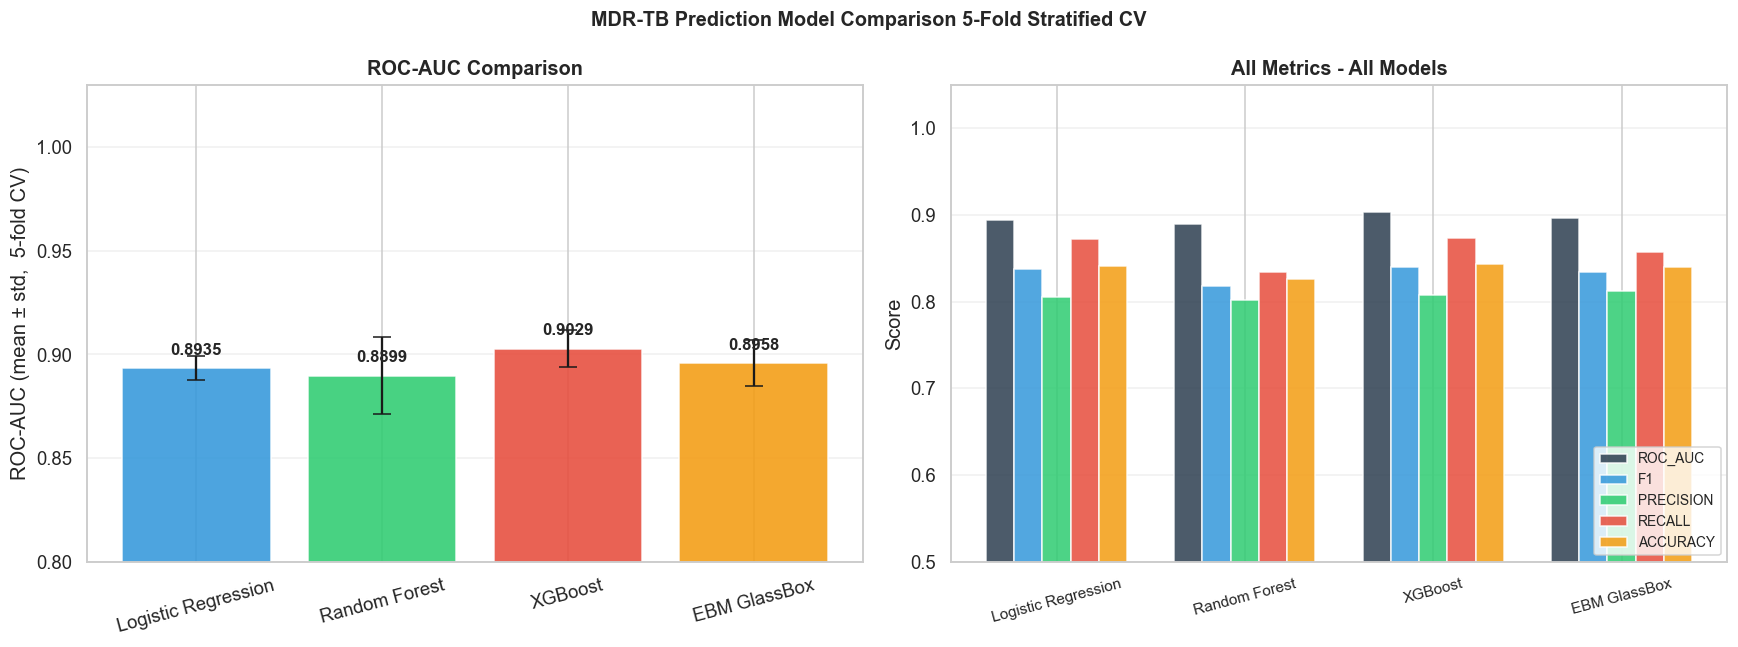

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#AUC with error bars
names  = list(all_cv.keys())
means  = [all_cv[n]['test_roc_auc'].mean() for n in names]
stds   = [all_cv[n]['test_roc_auc'].std()  for n in names]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

bars = axes[0].bar(names, means, color=colors, alpha=0.88, yerr=stds, capsize=6, error_kw={'linewidth':1.5})
for bar, mean in zip(bars, means):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{mean:.4f}', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
axes[0].set_ylabel('ROC-AUC (mean ± std,  5-fold CV)')
axes[0].set_title('ROC-AUC Comparison', fontweight='bold')
axes[0].set_ylim(0.8, 1.03)
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(True, alpha=0.3, axis='y')

#All metrics grouped bar
X      = np.arange(len(names))
width  = 0.15
mcols  = ['#2c3e50','#3498db','#2ecc71','#e74c3c','#f39c12']
for j, (m, mc) in enumerate(zip(METRICS, mcols)):
    ms = [all_cv[n][f'test_{m}'].mean() for n in names]
    axes[1].bar(X + j*width, ms, width, label=m.upper(), color=mc, alpha=0.85)

axes[1].set_xticks(X + width*2)
axes[1].set_xticklabels(names, fontsize=10, rotation=15)
axes[1].set_ylabel('Score')
axes[1].set_title('All Metrics - All Models', fontweight='bold')
axes[1].legend(fontsize=9, loc='lower right')
axes[1].set_ylim(0.5, 1.05)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle("MDR-TB Prediction Model Comparison 5-Fold Stratified CV", fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig(os.path.join(STEP4, 'obj2_model_comparison_chart.png'), bbox_inches='tight')
plt.show()

#### Per-Fold ROC-AUC - Stability Check

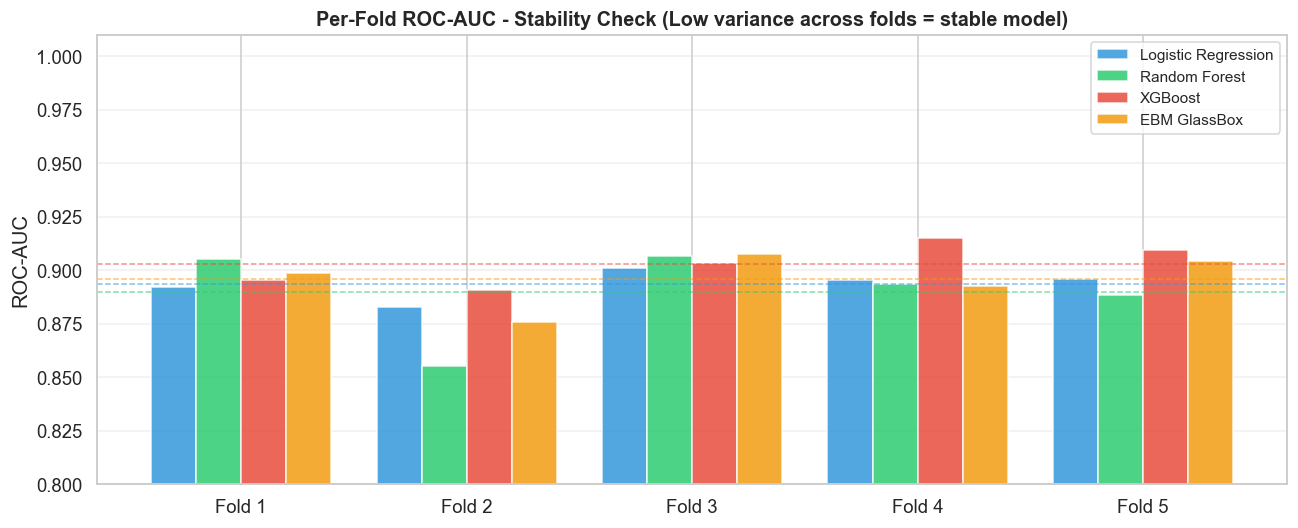

Saved: obj2_cv_per_fold.csv


In [22]:
fig, ax = plt.subplots(figsize=(12, 5))
X      = np.arange(N_FOLDS)
width  = 0.2
cols   = ['#3498db','#2ecc71','#e74c3c','#f39c12']

for j, (name, color) in enumerate(zip(names, cols)):
    fold_aucs = all_cv[name]['test_roc_auc']
    ax.bar(X + j*width, fold_aucs, width, label=name, color=color, alpha=0.85)
    ax.axhline(fold_aucs.mean(), color=color, ls='--', lw=1, alpha=0.6)

ax.set_xticks(X + width*1.5)
ax.set_xticklabels([f'Fold {i+1}' for i in range(N_FOLDS)])
ax.set_ylabel('ROC-AUC')
ax.set_title('Per-Fold ROC-AUC - Stability Check (Low variance across folds = stable model)', fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0.8, 1.01)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(STEP4, 'obj2_per_fold_auc.png'), bbox_inches='tight')
plt.show()

# Save per-fold results
cv_rows = []
for name, cv in all_cv.items():
    for fold in range(N_FOLDS):
        row = {'model': name, 'fold': fold+1}
        for m in METRICS:
            row[m] = round(cv[f'test_{m}'][fold], 4)
        cv_rows.append(row)
pd.DataFrame(cv_rows).to_csv(os.path.join(STEP4, 'obj2_cv_per_fold.csv'), index=False)
print("Saved: obj2_cv_per_fold.csv")

#### Confusion Matrices

Fitting all pipelines on full data for confusion matrix plots...


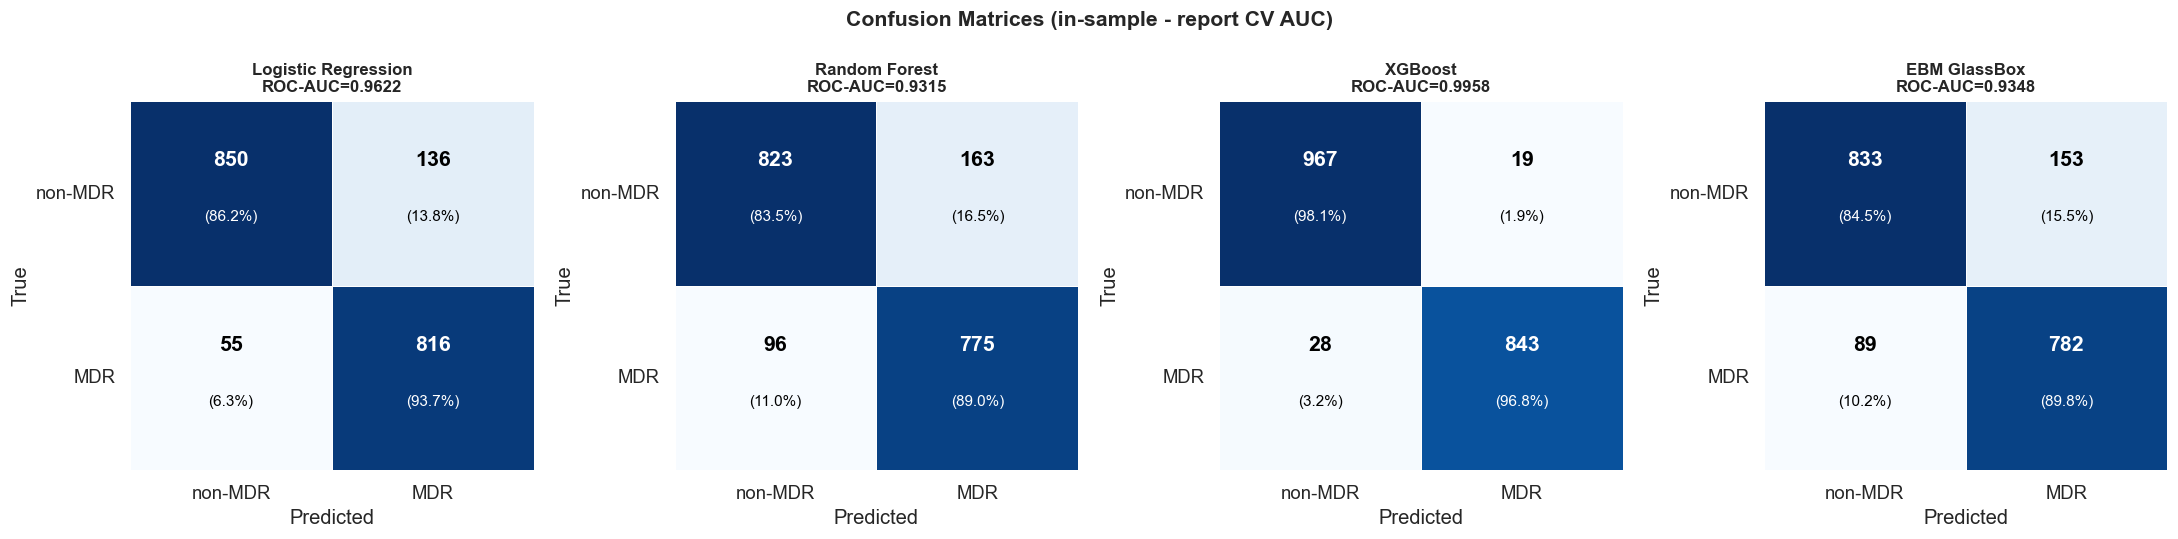


NOTE: AUC shown here is IN-SAMPLE (optimistic - model saw this data during training)
For publication always report the 5-fold CV AUC from cross_validate() above


In [23]:
print("Fitting all pipelines on full data for confusion matrix plots...")
pipes = {
    'Logistic Regression': lor_pipe,
    'Random Forest'      : rf_pipe,
    'XGBoost'            : xgb_pipe,
    'EBM GlassBox'       : ebm_pipe,
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (name, pipe) in zip(axes, pipes.items()):

    # Predict on full data — these are IN-SAMPLE predictions
    # Pipeline handles the transform (chi2 + float32) internally
    y_pred = pipe.predict(x)
    y_prob = pipe.predict_proba(x)[:, 1]

    # Confusion matrix
    cm     = confusion_matrix(y, y_pred)
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(cm, annot=False, ax=ax, cmap='Blues', cbar=False,
                linewidths=0.5, linecolor='white')

    for i in range(2):
        for j in range(2):
            dark       = cm[i, j] > cm.max() * 0.5
            text_color = 'white' if dark else 'black'
            ax.text(j + 0.5, i + 0.35, f'{cm[i, j]}',
                    ha='center', fontsize=14, fontweight='bold', color=text_color)
            ax.text(j + 0.5, i + 0.65, f'({cm_pct[i, j]:.1f}%)',
                    ha='center', fontsize=10, color=text_color)

    auc = roc_auc_score(y, y_prob)
    ax.set_xticklabels(['non-MDR', 'MDR'])
    ax.set_yticklabels(['non-MDR', 'MDR'], rotation=0)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{name}\nROC-AUC={auc:.4f}', fontweight='bold', fontsize=11)

plt.suptitle('Confusion Matrices (in-sample - report CV AUC)',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(STEP4, 'obj2_confusion_matrices.png'), bbox_inches='tight')
plt.show()

print()
print("NOTE: AUC shown here is IN-SAMPLE (optimistic - model saw this data during training)")
print("For publication always report the 5-fold CV AUC from cross_validate() above")

#### Feature Importance - Random Forest (Top 30)

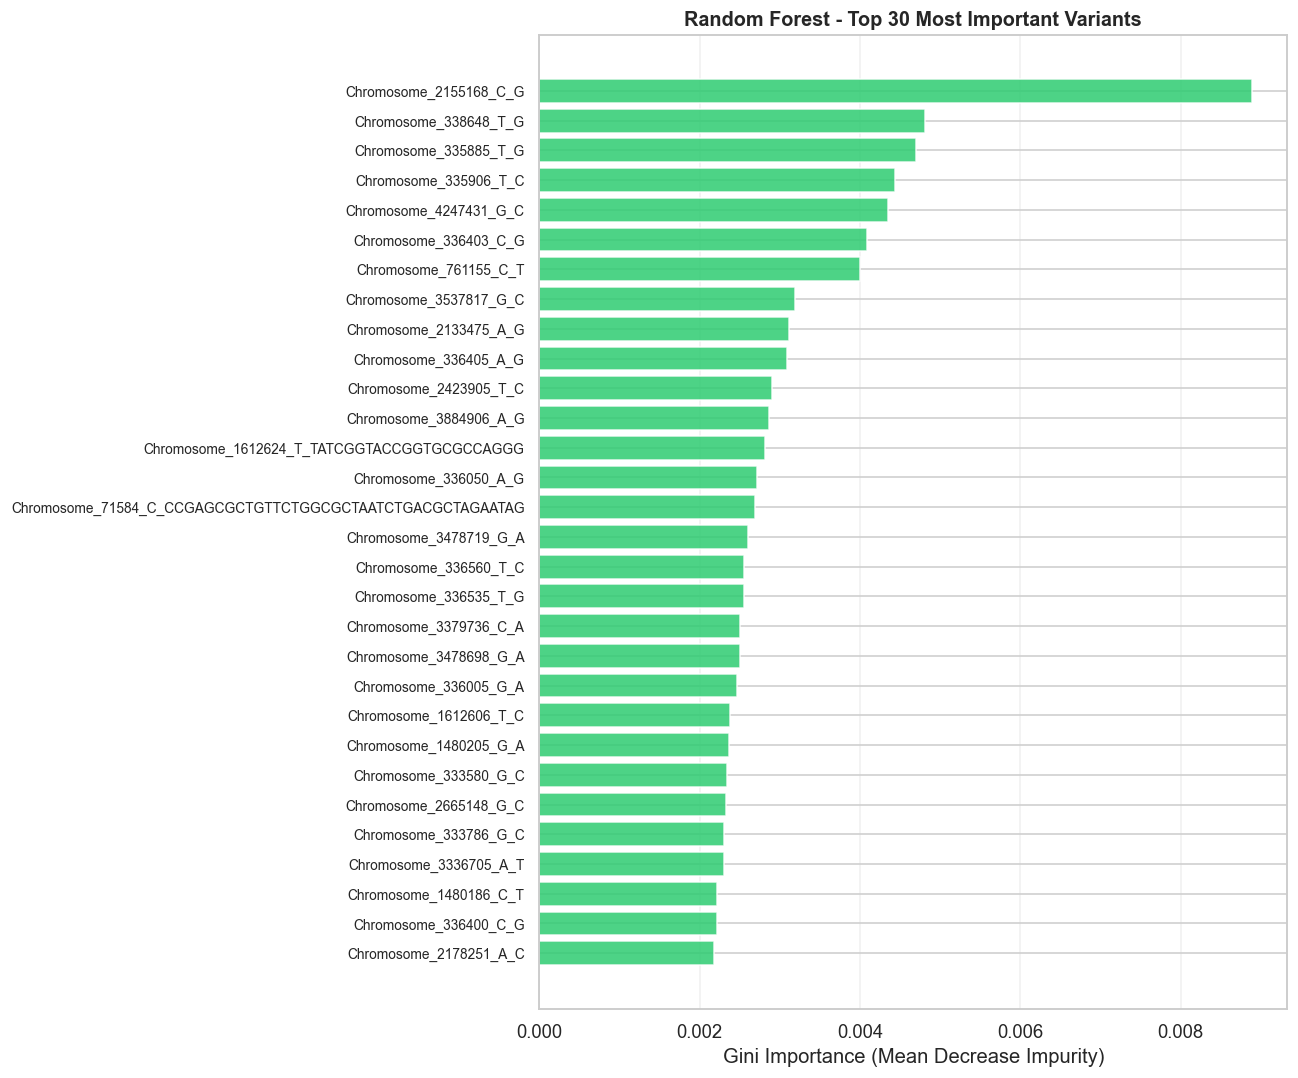

Saved: obj2_rf_top30_features.csv

 rank             variant_id  importance
    1 Chromosome_2155168_C_G    0.008884
    2  Chromosome_338648_T_G    0.004816
    3  Chromosome_335885_T_G    0.004699
    4  Chromosome_335906_T_C    0.004437
    5 Chromosome_4247431_G_C    0.004351
    6  Chromosome_336403_C_G    0.004087
    7  Chromosome_761155_C_T    0.003997
    8 Chromosome_3537817_G_C    0.003186
    9 Chromosome_2133475_A_G    0.003110
   10  Chromosome_336405_A_G    0.003086


In [24]:
rf_imp    = rf_pipe['model'].feature_importances_
top30_idx = rf_imp.argsort()[-30:][::-1]

top30_rf = pd.DataFrame({
    'rank'      : range(1, 31),
    'variant_id': [feature_names[i] for i in top30_idx],
    'importance': rf_imp[top30_idx],
})

fig, ax = plt.subplots(figsize=(12, 10))
ax.barh(range(30), top30_rf['importance'].values[::-1], color='#2ecc71', alpha=0.85)
ax.set_yticks(range(30))
ax.set_yticklabels(top30_rf['variant_id'].values[::-1], fontsize=9)
ax.set_xlabel('Gini Importance (Mean Decrease Impurity)')
ax.set_title('Random Forest - Top 30 Most Important Variants', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(os.path.join(STEP4, 'obj2_rf_importance.png'), bbox_inches='tight')
plt.show()

top30_rf.to_csv(os.path.join(STEP4, 'obj2_rf_top30_features.csv'), index=False)
print("Saved: obj2_rf_top30_features.csv")
print()
print(top30_rf.head(10).to_string(index=False))

#### Feature Importance - XGBoost (Top 30, by Gain)

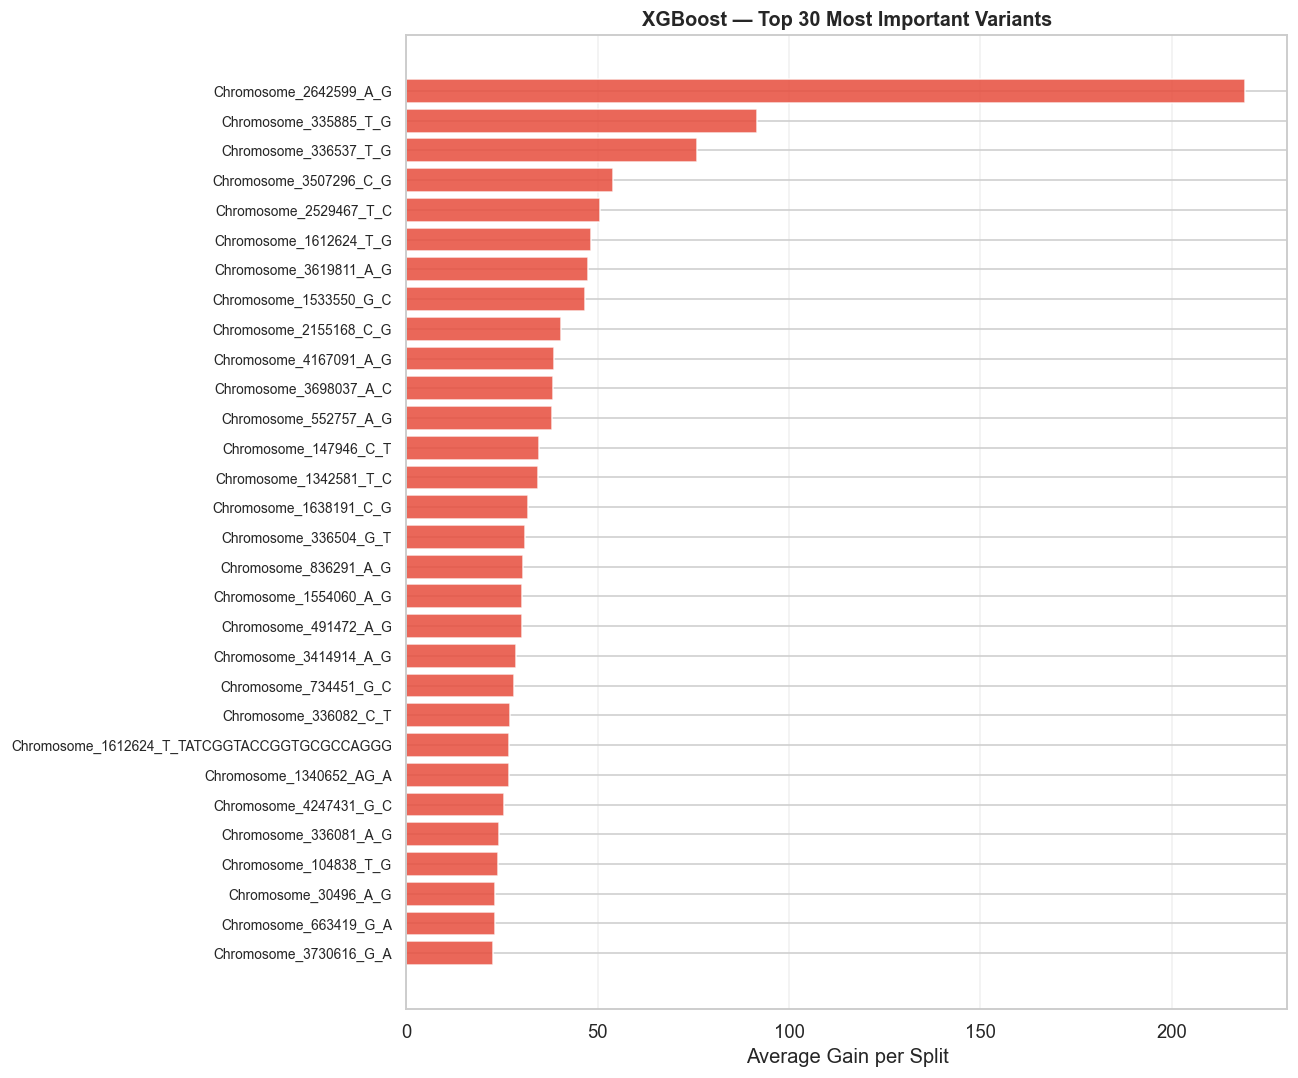

Saved: obj2_xgb_top30_features.csv

 rank             variant_id       gain
    1 Chromosome_2642599_A_G 219.242401
    2  Chromosome_335885_T_G  91.520081
    3  Chromosome_336537_T_G  75.897537
    4 Chromosome_3507296_C_G  53.870361
    5 Chromosome_2529467_T_C  50.549347
    6 Chromosome_1612624_T_G  48.297382
    7 Chromosome_3619811_A_G  47.448624
    8 Chromosome_1533550_G_C  46.734119
    9 Chromosome_2155168_C_G  40.339973
   10 Chromosome_4167091_A_G  38.628784


In [25]:
xgb_imp_raw = xgb_pipe['model'].get_booster().get_score(importance_type='gain')

xgb_imp_df = pd.DataFrame([
    {'feat_idx': int(k[1:]) if k.startswith('f') else 0, 'gain': v}
    for k, v in xgb_imp_raw.items()
]).sort_values('gain', ascending=False).head(30).reset_index(drop=True)

xgb_imp_df['variant_id'] = xgb_imp_df['feat_idx'].apply(
    lambda i: feature_names[i] if i < len(feature_names) else str(i))
xgb_imp_df['rank'] = range(1, len(xgb_imp_df)+1)

fig, ax = plt.subplots(figsize=(12, 10))
ax.barh(range(len(xgb_imp_df)), xgb_imp_df['gain'].values[::-1],
        color='#e74c3c', alpha=0.85)
ax.set_yticks(range(len(xgb_imp_df)))
ax.set_yticklabels(xgb_imp_df['variant_id'].values[::-1], fontsize=9)
ax.set_xlabel('Average Gain per Split')
ax.set_title('XGBoost — Top 30 Most Important Variants', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(os.path.join(STEP4, 'obj2_xgb_importance.png'), bbox_inches='tight')
plt.show()

xgb_imp_df[['rank','variant_id','gain']].to_csv(
    os.path.join(STEP4, 'obj2_xgb_top30_features.csv'), index=False)
print("Saved: obj2_xgb_top30_features.csv")
print()
print(xgb_imp_df[['rank','variant_id','gain']].head(10).to_string(index=False))

#### EBM GlassBox - Native Feature Importance

EBM importance scores are directly interpretable:  
each score = mean absolute contribution of that variant to the MDR probability prediction.  
No SHAP post-processing needed - the EBM shape functions ARE the explanation.


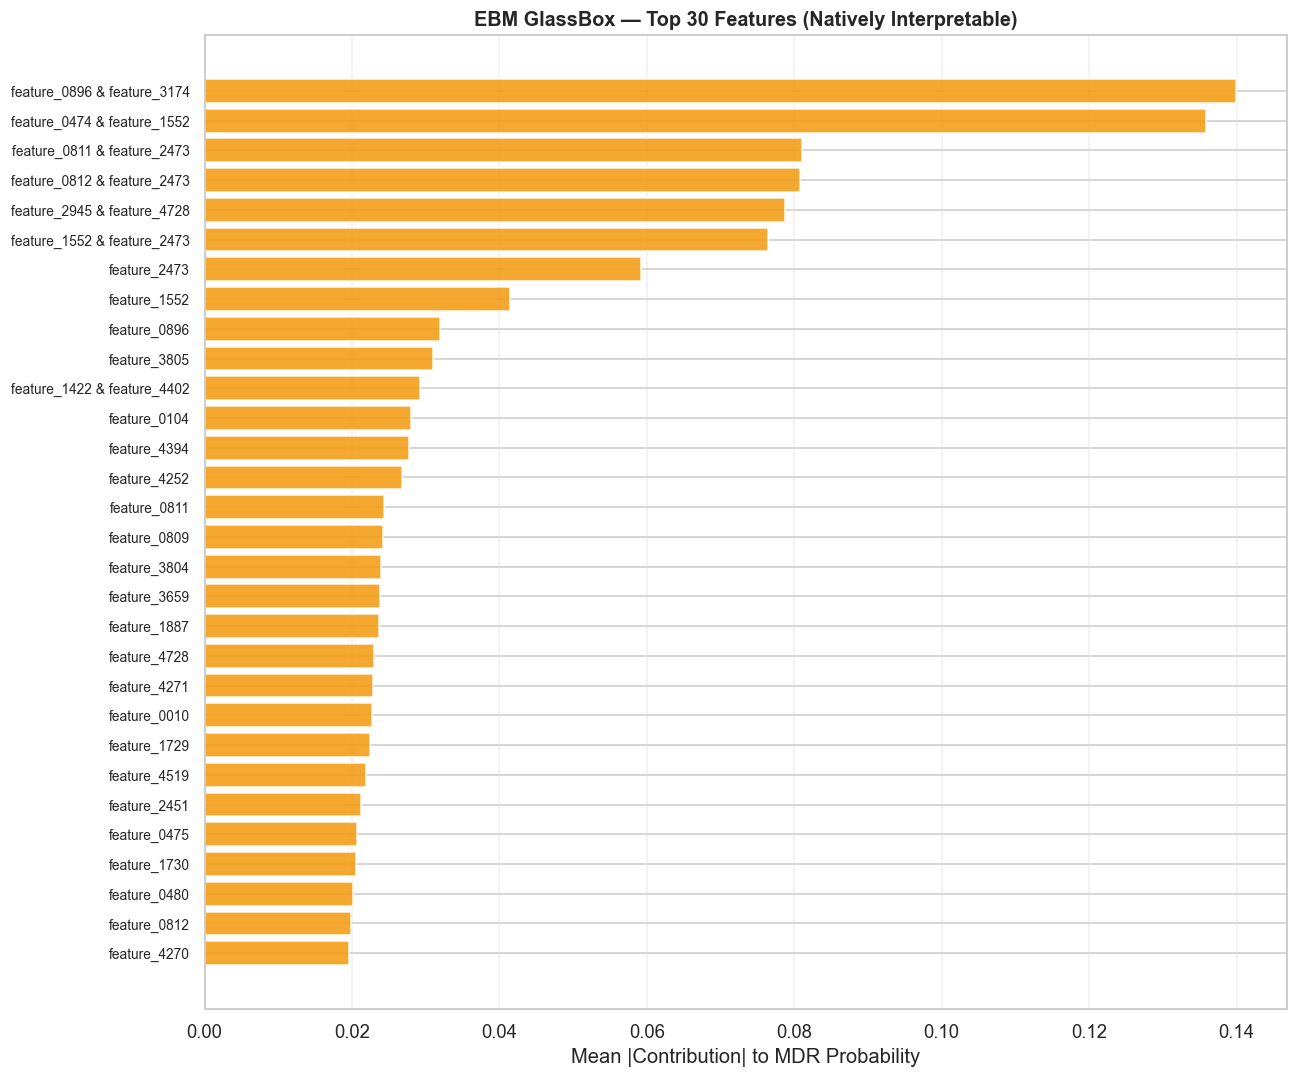

Saved: obj2_ebm_feature_importance.csv

 rank                     feature  importance
    1 feature_0896 & feature_3174    0.139908
    2 feature_0474 & feature_1552    0.135862
    3 feature_0811 & feature_2473    0.080990
    4 feature_0812 & feature_2473    0.080788
    5 feature_2945 & feature_4728    0.078750
    6 feature_1552 & feature_2473    0.076406
    7                feature_2473    0.059217
    8                feature_1552    0.041459
    9                feature_0896    0.031927
   10                feature_3805    0.030988


In [26]:
ebm_exp    = ebm_pipe['model'].explain_global()
ebm_names  = ebm_exp.data()['names']
ebm_scores = ebm_exp.data()['scores']

ebm_imp_df = pd.DataFrame({'feature': ebm_names, 'importance': ebm_scores})
ebm_imp_df = ebm_imp_df.sort_values('importance', ascending=False).reset_index(drop=True)
ebm_imp_df['rank'] = range(1, len(ebm_imp_df)+1)

top30_ebm = ebm_imp_df.head(30)

fig, ax = plt.subplots(figsize=(12, 10))
ax.barh(range(len(top30_ebm)), top30_ebm['importance'].values[::-1],
        color='#f39c12', alpha=0.88)
ax.set_yticks(range(len(top30_ebm)))
ax.set_yticklabels(top30_ebm['feature'].values[::-1], fontsize=9)
ax.set_xlabel('Mean |Contribution| to MDR Probability')
ax.set_title('EBM GlassBox — Top 30 Features (Natively Interpretable)',
             fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(os.path.join(STEP4, 'obj2_ebm_importance.png'), bbox_inches='tight')
plt.show()

ebm_imp_df.to_csv(os.path.join(STEP4, 'obj2_ebm_feature_importance.csv'), index=False)
print("Saved: obj2_ebm_feature_importance.csv")
print()
print(top30_ebm[['rank','feature','importance']].head(10).to_string(index=False))

#### Consensus Features - Top 100 Across All Three Models

Features in the top 100 of **all three models** (RF, XGBoost, EBM) are the  
most robust genomic predictors of MDR - agreed upon by independent algorithms.  
These are the features to highlight in the publication.


In [27]:
rf_top100  = set(feature_names[i] for i in rf_imp.argsort()[-100:][::-1])
xgb_top100 = set(xgb_imp_df['variant_id'].head(100).tolist())
ebm_top100 = set(ebm_imp_df['feature'].head(100).tolist())

in_all3    = rf_top100 & xgb_top100 & ebm_top100
in_rf_xgb  = rf_top100 & xgb_top100
in_rf_ebm  = rf_top100 & ebm_top100
in_xgb_ebm = xgb_top100 & ebm_top100

print(f"  In top 100 of ALL 3 models  : {len(in_all3):>3}  ← strongest evidence")
print(f"  In top 100 of RF + XGB      : {len(in_rf_xgb):>3}")
print(f"  In top 100 of RF + EBM      : {len(in_rf_ebm):>3}")
print(f"  In top 100 of XGB + EBM     : {len(in_xgb_ebm):>3}")

# Build ranked consensus table
feat_list = rf_imp.argsort()[::-1].tolist()
rf_ranks  = {feature_names[i]: r+1 for r, i in enumerate(feat_list)}

consensus = []
for feat in in_all3:
    xr = (xgb_imp_df[xgb_imp_df['variant_id'] == feat].index[0] + 1
          if feat in xgb_imp_df['variant_id'].values else 9999)
    er = (ebm_imp_df[ebm_imp_df['feature'] == feat].index[0] + 1
          if feat in ebm_imp_df['feature'].values else 9999)
    rr = rf_ranks.get(feat, 9999)
    consensus.append({
        'variant_id'  : feat,
        'rf_rank'     : rr,
        'xgb_rank'    : xr,
        'ebm_rank'    : er,
        'mean_rank'   : round(np.mean([rr, xr, er]), 1),
    })


if len(consensus) > 0:
    consensus_df = pd.DataFrame(consensus).sort_values('mean_rank').reset_index(drop=True)
    consensus_df.insert(0, 'consensus_rank', range(1, len(consensus_df) + 1))
    consensus_df.to_csv(os.path.join(STEP4, 'obj2_consensus_features.csv'), index=False)

    print(f"\nTop 20 consensus features (in top 100 of all 3 models):")
    print(consensus_df.head(20).to_string(index=False))
    print(f"\nSaved: obj2_consensus_features.csv")
else:
    print("\nNo overlapping features found in the top 100 of all 3 models.")
    print("CSV file 'obj2_consensus_features.csv' was not generated.")

  In top 100 of ALL 3 models  :   0  ← strongest evidence
  In top 100 of RF + XGB      :   8
  In top 100 of RF + EBM      :   0
  In top 100 of XGB + EBM     :   0

No overlapping features found in the top 100 of all 3 models.
CSV file 'obj2_consensus_features.csv' was not generated.


## 18. Final Summary

In [28]:
print("=" * 65)
print("STEP 4 COMPLETE")
print("=" * 65)
print()
print(f"{'Model':<22} {'ROC-AUC':>10} {'F1':>10} {'Precision':>10} {'Recall':>10}")
print("─" * 65)
for _, r in comp_df.iterrows():
    print(f"{r['Model']:<22} {r['ROC_AUC']:>10.4f} {r['F1']:>10.4f} "
          f"{r['PRECISION']:>10.4f} {r['RECALL']:>10.4f}")
print()

print("Output files:")
all_files = []
for dirpath, _, files in os.walk(STEP4):
    for fname in sorted(files):
        fpath = os.path.join(dirpath, fname)
        rel   = os.path.relpath(fpath, STEP4)
        size  = os.path.getsize(fpath)
        all_files.append((rel, size))
        print(f"  {rel:<48} {size/1024:>8.1f} KB")

print()
ram = psutil.virtual_memory()
print(f"Final RAM    : {ram.used/1e9:.1f} GB used | {ram.available/1e9:.1f} GB free")
print()
print("Next: step5_shap_analysis.ipynb — SHAP values on XGBoost")
print("  (Load xgb_pipeline.pkl or xgb_model.json)")

STEP 4 COMPLETE

Model                     ROC-AUC         F1  Precision     Recall
─────────────────────────────────────────────────────────────────
Logistic Regression        0.8935     0.8374     0.8053     0.8726
Random Forest              0.8899     0.8178     0.8023     0.8347
XGBoost                    0.9029     0.8395     0.8080     0.8737
EBM GlassBox               0.8958     0.8341     0.8120     0.8577

Output files:
  obj2_confusion_matrices.png                          73.9 KB
  obj2_cv_per_fold.csv                                  1.0 KB
  obj2_ebm_feature_importance.csv                     198.8 KB
  obj2_ebm_feature_importance_named.csv               248.8 KB
  obj2_ebm_importance.png                             100.3 KB
  obj2_model_comparison.csv                             0.4 KB
  obj2_model_comparison_chart.png                      92.6 KB
  obj2_per_fold_auc.png                                53.9 KB
  obj2_rf_importance.png                              147.1 KB
